In [1]:
#other imports
import os
import numpy as np
os.chdir('C:/Code/Github/GLM-analysis/')

In [2]:
from DataHandlerDecoding import DataHandlerDecoding as datafun
from Plotter import Plotter as plotterfun
from DecoderAnalyzer import DecoderAnalyzer as analysisdec

In [3]:
#initialize class
# decoded_variables= {'sound_category', 'choice', 'photostim', 'outcome','shuffled/sound_category', 'shuffled/choice', 'shuffled/photostim', 'shuffled/outcome'}
#decoded_variables= { 'photostim', 'shuffled/photostim'}
decoded_variables= { 'sound_category', 'shuffled/sound_category'}

data_handler = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed
data_handler_pass = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed

In [4]:
# LOAD INFO ABOUT DATASETS
info_dir = 'V:/Connie/results/opto_2024/context/mod'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)
# for dat in datasets:
#     print(dat)

# Indices to remove (example: remove datasets at indices 0 and 2)
#remove_indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]

remove_indices = [8,22] #NO SOUND/CHOICE
#remove_indices = [24] #NO PHOTOSTIM (CONTROL MOUSE)
#remove_indices = [2,7,8,20,21,22] #NO OUTCOME


#remove_indices = [0,1,2,4,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] testing with 2 datasets

# Remove indices from both lists
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]
for dat in datasets:
    print(dat)

('HA11-1R', '2023-05-05', 'V:')
('HA11-1R', '2023-04-13', 'V:')
('HA2-1L', '2023-04-12', 'V:')
('HA2-1L', '2023-05-05', 'V:')
('HA1-00', '2023-06-29', 'V:')
('HA1-00', '2023-08-28', 'W:')
('HE4-1L1R', '2023-08-21', 'W:')
('HE4-1L1R', '2023-08-24', 'W:')
('HA10-1L', '2023-04-17', 'V:')
('HA10-1L', '2023-04-12', 'V:')
('HA11-1R', '2023-04-07', 'V:')
('HA11-1R', '2023-05-01', 'V:')
('HA11-1R', '2023-05-02', 'V:')
('HA2-1L', '2023-04-28', 'V:')
('HA2-1L', '2023-05-01', 'V:')
('HA1-00', '2023-06-27', 'V:')
('HA1-00', '2023-07-07', 'W:')
('HA1-00', '2023-08-25', 'W:')
('HE4-1L1R', '2023-08-14', 'W:')
('HE4-1L1R', '2023-08-28', 'W:')
('HE4-1L1R', '2023-09-04', 'W:')
('HA10-1L', '2023-03-31', 'V:')
('HE1-00', '2023-05-30', 'V:')


In [5]:
#LOAD ACTUAL DATASETS 
save_results = os.path.join(f'V:/Connie/results/glm_decoding/prelim')
os.makedirs(save_results, exist_ok=True)
cat_results = []
cat_results_pass = []

model_type = 'GLM_3nmf_pre'
results_pre,results_pre_all_sb, cat_results, celltype_info = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 

# results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives means across sc or pop

model_type = 'GLM_3nmf_passive'
results_pass,results_pass_all_sb, cat_results_pass, celltype_info = data_handler_pass.process_multiple_datasets(datasets, model_type,single_balanced=True) 

Processing dataset: HA11-1R_2023-05-05
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/1_1/
decoder_results_regular_sound_category.mat
decoder_results_shuffled_sound_category.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/2_1/
decoder_results_regular_sound_category.mat
decoder_results_shuffled_sound_category.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/3_1/
decoder_results_regular_sound_category.mat
decoder_results_shuffled_sound_category.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/4_1/
decoder_results_regular_sound_category.mat
decoder_results_shuffled_sound_category.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/5_1/
decoder_results_regular_sound_category.mat
decoder_results_shuffled_sound_category.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/6_1/
decoder_results_regular_sound_category.mat
decoder_results_shuffled_sound_category.mat
V:/Connie/Processed

In [6]:
#Initialize plotting class

# Define colors dictionary
colors_dict = {
    'pyr': (0.37, 0.75, 0.49), 
    'som': (0.17, 0.35, 0.8), 
    'pv': (0.82, 0.04, 0.04)
}

plotter = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results)

In [7]:
# for dataset in results_pre_all_sb:
#     print(dataset)
#     print(np.shape(results_pre_all_sb[dataset]['photostim']['sc_cumulative_information_mean']))

# del results_pre_all_sb['HE1-00_2023-05-30']

#np.shape(results_pass_all_sb['HE1-00_2023-05-30']['shuffled/sound_category']['sc_cumulative_information_mean'])
# for dataset in results_pre_all_sb:
#     print(np.shape(cat_results[dataset]['shuffled/sound_category'][2]['sc_cumulative_information']))
# del cat_results['HE4-1L1R_2023-08-21']

In [8]:
# Get shuffled data into frames x neurons x total shuffles across splits (50 * 10 = 500)

shuffled_structure = data_handler.create_shuffled_distribution_structure(decoder_type = list(decoded_variables)[0], metric = 'sc_instantaneous_information')
shuffled_structure_pass = data_handler_pass.create_shuffled_distribution_structure(decoder_type = list(decoded_variables)[0], metric = 'sc_instantaneous_information')

HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-04-12
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-17
HA10-1L_2023-04-12
HA11-1R_2023-04-07
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HA10-1L_2023-03-31
HE1-00_2023-05-30
HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-04-12
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-17
HA10-1L_2023-04-12
HA11-1R_2023-04-07
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HA10-1L_2023-03-31
HE1-00_2023-05-30


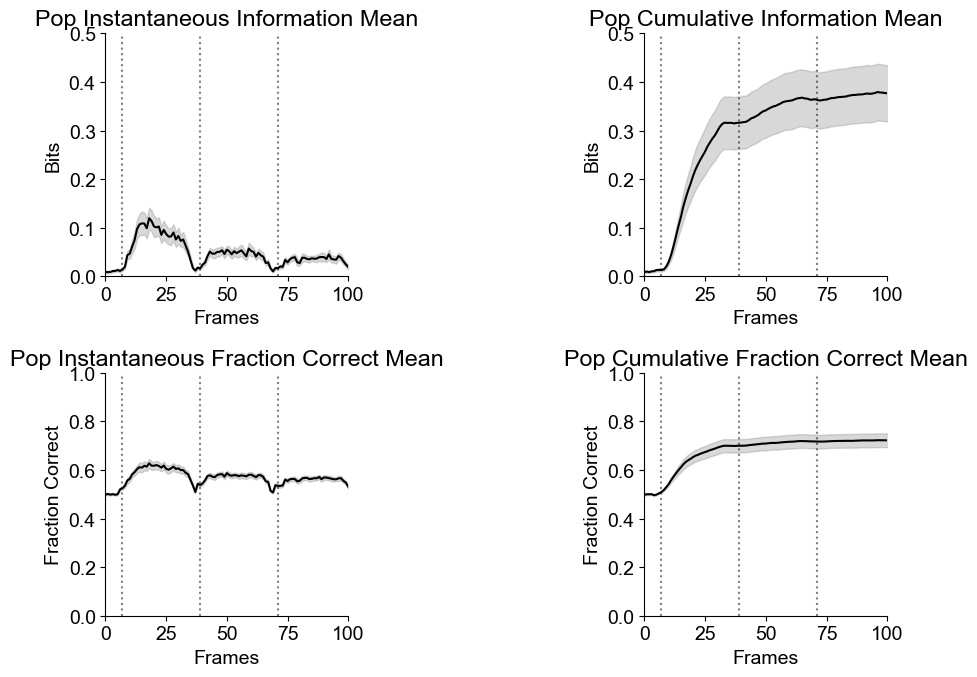

In [31]:
# Plot population decoders across datasets
current_model_type = 'pre'
results_pre_all = results_pre_all_sb 
current_decoder_type = 'sound_category'   
os.makedirs(f'{plotter.save_results}/{current_model_type}/', exist_ok=True)

# Usage example:
plotter.plot_decoding_results(results_pre_all, 
                     decoder_type= current_decoder_type,
                     plot_type='pop', # or sc
                     save_dir=f'{plotter.save_results}/{current_model_type}', #,save_dir = f'{save_results}/{current_decoder_type}_{current_model_type}_pop'
                     xlim = (0,100),
                     ylim = [0.5, 0.5, 1, 1]) #define y limits for each subplot

In [11]:
# Create an instance of AnalysisManager, passing in the plotter module
analysis_dec = analysisdec(celltype_info)

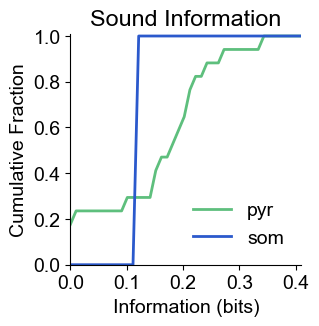

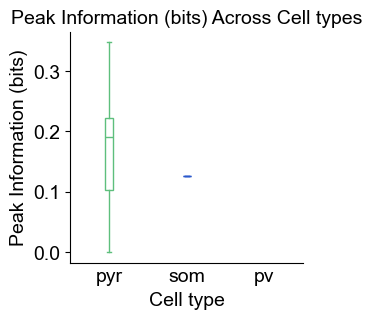

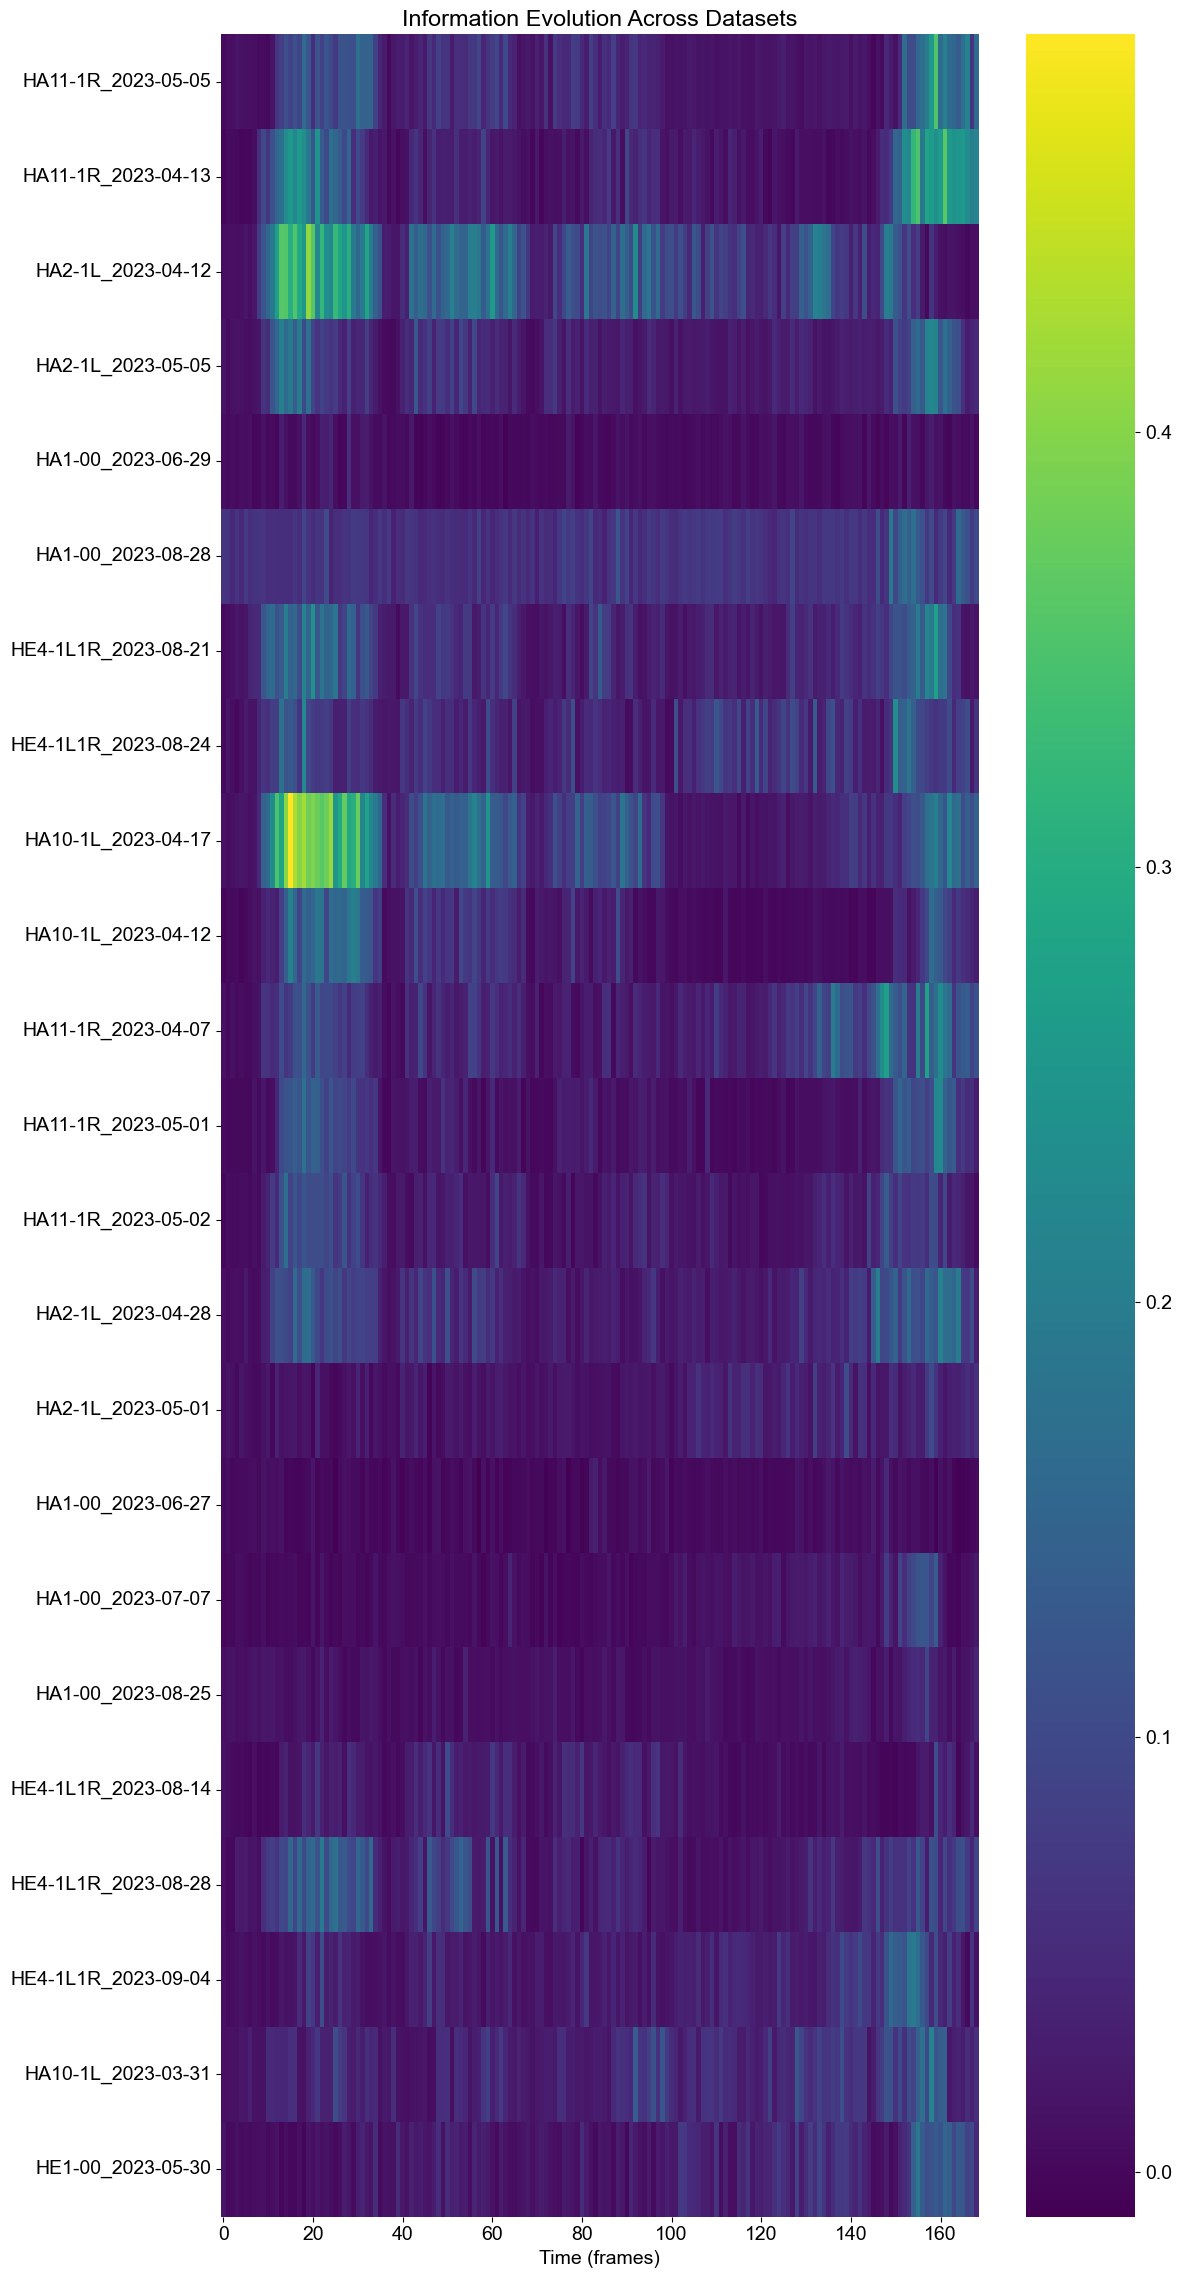

In [57]:
#DECIDE WHETHER OR NOT TO USE END FRAME
start_frame = 14 #before this there is artifact
end_frame = 100 #100 for sound/photostim
threshold = None #use threshold OR percentile to decide signficant neurons
# Replace dot with underscore in threshold for directory name
threshold_str = str(threshold).replace('.', '_')
# save_path = f'{plotter.save_results}/{current_model_type}/{threshold_str}'
# save_path = os.path.join(plotter.save_results, current_model_type, threshold_str)
# print(save_path)
# os.makedirs(save_path, exist_ok=True)
save_path = f'{plotter.save_results}/{current_model_type}/'

peaks_by_celltype = analysis_dec.analyze_peaks_by_celltype( results_pre_all,shuffled_structure,
                                                            decoder_type=current_decoder_type, start_frame=start_frame , end_frame = end_frame,
                                                            significance_percentile = 95, threshold = threshold) #, end_frame = 100

#PLOT DISTRIBUTIONS OF SIGINIFICANT NEURONS!
metric_to_plot = 'sc_instantaneous_information_mean'
cdf_data, cell_labels = analysis_dec.format_peaks_for_cdf(peaks_by_celltype,metric = metric_to_plot, significant_only=True)
all_peaks, neuron_groups = analysis_dec.format_peaks_for_boxplot(peaks_by_celltype, metric = metric_to_plot, significant_only=True)

#cdf
plotter.plot_cdf_coupling_index(np.array(cdf_data['all']['peaks']),
                                cell_labels,
                                colors = plotter.celltypecolors,
                                title='Sound Information',
                                xlabel = 'Information (bits)',
                                xval=.4,
                                xint=0.1,
                                save_path=f'{save_path}{current_decoder_type}_cdf_thr{threshold_str}.png')

#make boxplot!
plotter.box_plot(
    data=all_peaks,
    neuron_groups=neuron_groups,
    colors=plotter.celltypecolors,
    measure_string='Peak Information (bits)',
    save_path=f'{save_path}{current_decoder_type}_box_plot_thr{threshold_str}.png'
)

#heatmap across datasets
plotter.plot_decoding_heatmap_datasets(results_pre_all, decoder_type= current_decoder_type, metric = 'pop_instantaneous_information_mean')


In [65]:
# PRINT OUT # OF SIGNIFICANT NEURONS PER CELL TYPE
# Assuming cdf_data is a dictionary with cell types as keys and peaks as values
for cell_type, data in cdf_data.items():
    if 'peaks' in data:
        num_significant_neurons = len(np.array(data['peaks']))
        print(f'Cell type: {cell_type}, Number of significant neurons: {num_significant_neurons}')

Cell type: pyr, Number of significant neurons: 17
Cell type: som, Number of significant neurons: 1
Cell type: pv, Number of significant neurons: 0
Cell type: all, Number of significant neurons: 18


In [15]:
def visualize_single_neuron_analysis(results_dict,shuffled_structure , plotter, analyzer, decoder_type='sound_category', start_frame=14, end_frame=None, metric = 'sc_instantaneous_information_mean', significance_percentile = 95, threshold = None, save_path=None):
    """Orchestrate single neuron analysis and visualization."""

    significant_neurons_data, significance_struc = analyzer.analyze_significant_neurons(results_dict,shuffled_structure, decoder_type, start_frame, end_frame,metric ,significance_percentile)
    
    #using threshold to get significant neurons? threshold_value = 0.06
    if threshold is not None:
        significant_neurons_data, significance_struc = analyzer.analyze_significant_neurons_by_threshold(results_dict, decoder_type, start_frame, end_frame,metric,threshold)
    
    # Extract significant neurons for each dataset
    significant_neurons = {dataset: np.concatenate([significant_neurons_data[dataset][celltype] for celltype in significant_neurons_data[dataset]]) 
                           for dataset in significant_neurons_data}
    
    # Plot the heatmap, only using significant neurons if they exist
    #plotter.plot_neuron_performance_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons) #separated by datasets

    plotter.plot_significant_neurons_distribution(significance_struc,save_path=save_path) 

    plotter.plot_time_course_by_cell_type(results_dict, decoder_type, start_frame = 0, end_frame = end_frame, metric = metric)

    plotter.plot_summary_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons, save_path=save_path) #combined across datasets

    plotter.plot_significant_neuron_percentages_by_celltype(significant_neurons, celltype_info,  save_path=save_path)

    return significant_neurons_data

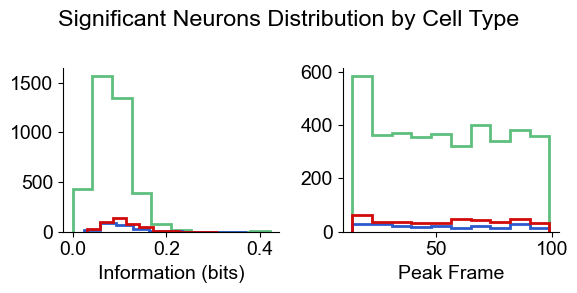

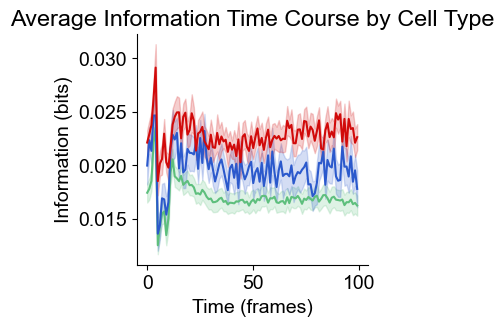

c:\Code\Github\GLM-analysis\Plotter.py:1216: RuntimeWarning: invalid value encountered in divide
  normalized_data = data / max_values  # Normalize by Imax for each neuron


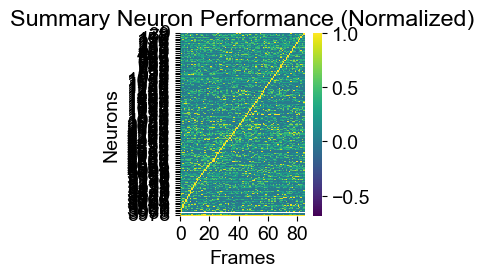

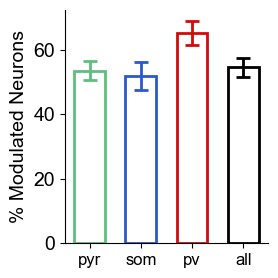

Significantly Modulated Neurons (% ± SEM):
pyr: 53.58 ± 2.91%
som: 51.88 ± 4.37%
pv: 65.21 ± 3.77%
all: 54.63 ± 2.90%


In [17]:
# Call the visualization function
significant_neurons_data = visualize_single_neuron_analysis(
    results_dict=results_pre_all,
    shuffled_structure = shuffled_structure,
    plotter=plotter,
    analyzer =analysis_dec,
    decoder_type = current_decoder_type,  # Or your preferred decoder type
    start_frame = 14,                 # Specify start frame
    end_frame = 100,                    # Specify end frame if needed, else None
    metric = 'sc_instantaneous_information_mean', #choose sc metric to look at
    significance_percentile = 95,         #used to determine significant cells
    threshold = None,                   #None or 0.06 (from Runyan 2017)
    save_path= f'{save_path}{current_decoder_type}_sig_cel_thr{threshold_str}.png'
)

In [18]:
significant_neurons_data

{'HA11-1R_2023-05-05': {'pyr': [0,
   1,
   2,
   3,
   5,
   8,
   9,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   24,
   26,
   27,
   29,
   30,
   31,
   32,
   33,
   34,
   36,
   37,
   39,
   40,
   42,
   44,
   45,
   46,
   49,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   61,
   62,
   63,
   64,
   65,
   67,
   70,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   92,
   95,
   96,
   98,
   99,
   100,
   101,
   102,
   103,
   104,
   105,
   108,
   110,
   111,
   113,
   117,
   119,
   120,
   121,
   123,
   125,
   126,
   127,
   128,
   129,
   130,
   131,
   134,
   136,
   139,
   140,
   141,
   144,
   146,
   147,
   148,
   150,
   152,
   154,
   155,
   156,
   157,
   160,
   161,
   162,
   163,
   164,
   165,
   166,
   168,
   169,
   170,
   172,
   173,
   174,
   175,
   176,
   178,
   180,
   181,
   183,
   184,
   185,
   186,
  